# Dense vs sparse — example01 visual comparison

Overlays every quantity produced by `main.py` (dense) and `main_sparse.py` (sparse backend)
with a residual panel underneath each plot. Run all cells and judge the agreement visually.

- `REF_DIR` — dense reference outputs. **Note:** the checked-in `dense/` folder predates the
  numpy 2.2.6 / Python 3.14 fix (silent large-array corruption, ≤0.1% effect on DOS/transport);
  a freshly regenerated `output/` from `python main.py` is the cleaner reference.
- `SPARSE_DIR` — sparse outputs from `python main_sparse.py` (or `mpirun -n 4 python main_sparse.py`).
- `NSEL` — number of bands the sparse run computed (72 = `bnd` after doubling); the dense bands
  file has 144 columns, only the first `NSEL` are comparable.

Expected differences at `threshold = 1e-4`: bands ≲ 20 meV; DOS/PDOS and transport at the
percent level (truncation + adaptive-smearing gauge at exactly-degenerate folded bands).

Reading the residuals:

- **Isolated spikes in either DOS curve** (dense and sparse alike, at different random
  energies) are near-zero adaptive-smearing widths: cell doubling folds bands into exact
  degeneracies, where the diagonal velocity — and hence the Yates width `δ ∝ |v|` — is
  gauge-dependent; a width that lands near zero turns one k-point into a `1/δ` delta spike.
  Both codes roll this dice independently; it is not a sparse-backend defect.
- **Transport relative differences concentrate in the band gap**, where the tensors are
  orders of magnitude below their peaks and exponentially sensitive to meV band shifts;
  the Seebeck spike sits exactly at its zero crossing (relative difference of ~0).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

REF_DIR = 'output'          # dense reference ('dense' = pre-fix snapshot, 'output' = fresh run)
SPARSE_DIR = 'output_sparse'
NSEL = 72

# deep blue / vermillion / amber (Okabe-Ito)
C_DENSE, C_SPARSE, C_RESID = '#0072B2', '#D55E00', '#E69F00'

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

def paired_axes(height=(3.2, 1.1)):
    fig, (ax, res) = plt.subplots(2, 1, sharex=True, figsize=(8, sum(height)),
                                  height_ratios=height, constrained_layout=True)
    return fig, ax, res

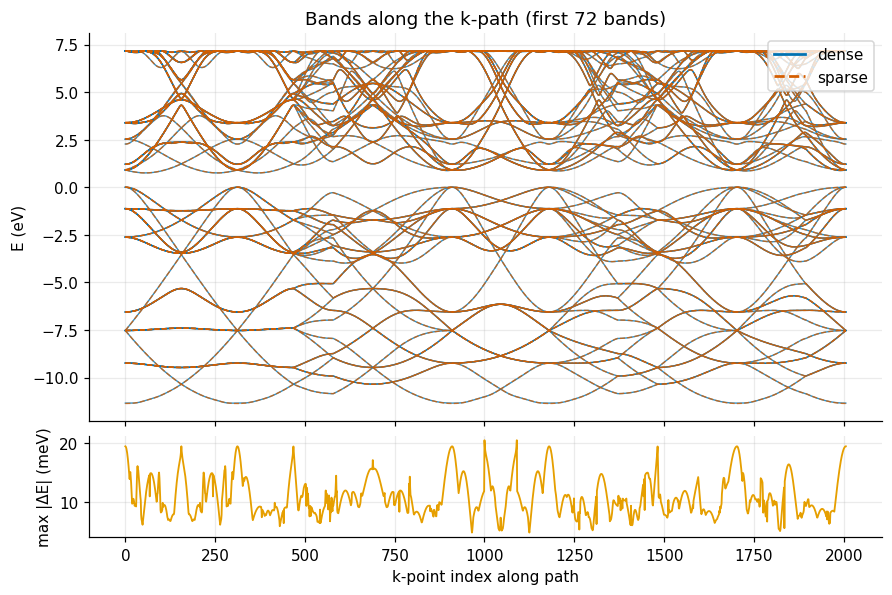

bands: max |ΔE| = 20.51 meV, mean = 2.872 meV


In [2]:
d = np.loadtxt(f'{REF_DIR}/bands_0.dat')[:, 1:1 + NSEL]
s = np.loadtxt(f'{SPARSE_DIR}/bands_0.dat')[:, 1:1 + NSEL]
x = np.arange(d.shape[0])

fig, ax, res = paired_axes((4.2, 1.1))
ax.plot(x, d, color=C_DENSE, lw=0.9, alpha=0.8)
ax.plot(x, s, color=C_SPARSE, lw=0.9, ls='--', alpha=0.8)
ax.set_ylabel('E (eV)')
ax.set_title(f'Bands along the k-path (first {NSEL} bands)')
ax.legend(handles=[plt.Line2D([], [], color=C_DENSE, lw=1.8, label='dense'),
                   plt.Line2D([], [], color=C_SPARSE, lw=1.8, ls='--', label='sparse')],
          loc='upper right')
res.plot(x, np.abs(d - s).max(axis=1) * 1e3, color=C_RESID, lw=1.2)
res.set_ylabel('max |ΔE| (meV)')
res.set_xlabel('k-point index along path')
plt.show()
print(f'bands: max |ΔE| = {np.abs(d - s).max()*1e3:.2f} meV, mean = {np.abs(d - s).mean()*1e3:.3f} meV')

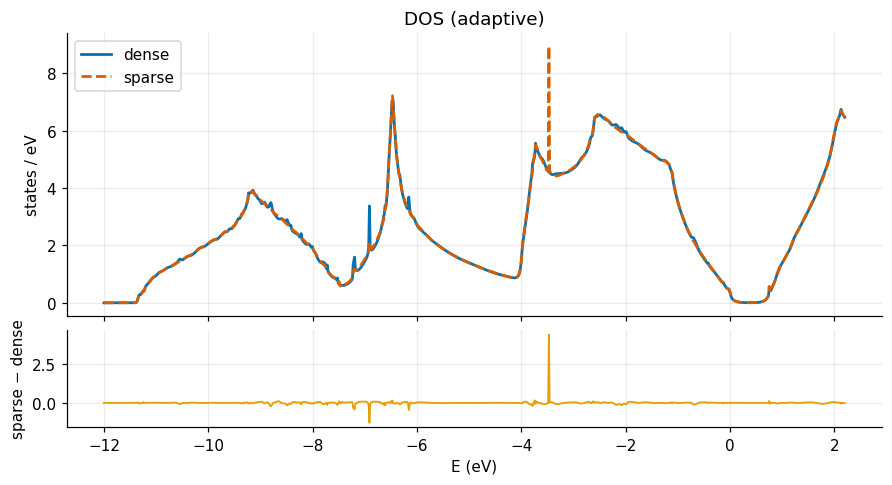

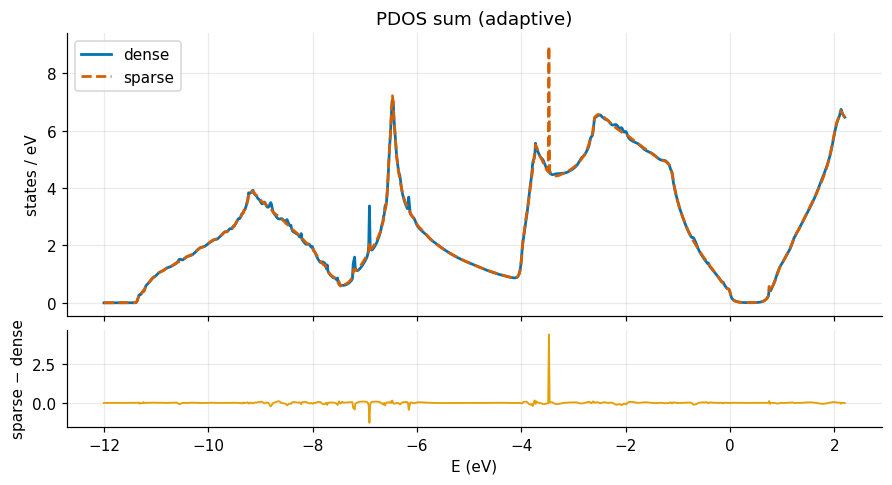

In [3]:
for fname, label in [('dosdk_0.dat', 'DOS (adaptive)'), ('pdosdk_sum_0.dat', 'PDOS sum (adaptive)')]:
    a = np.loadtxt(f'{REF_DIR}/{fname}')
    b = np.loadtxt(f'{SPARSE_DIR}/{fname}')
    fig, ax, res = paired_axes()
    ax.plot(a[:, 0], a[:, 1], color=C_DENSE, lw=1.8, label='dense')
    ax.plot(b[:, 0], b[:, 1], color=C_SPARSE, lw=1.8, ls='--', label='sparse')
    ax.set_ylabel('states / eV')
    ax.set_title(label)
    ax.legend(loc='upper left')
    res.plot(a[:, 0], b[:, 1] - a[:, 1], color=C_RESID, lw=1.2)
    res.set_ylabel('sparse − dense')
    res.set_xlabel('E (eV)')
    plt.show()

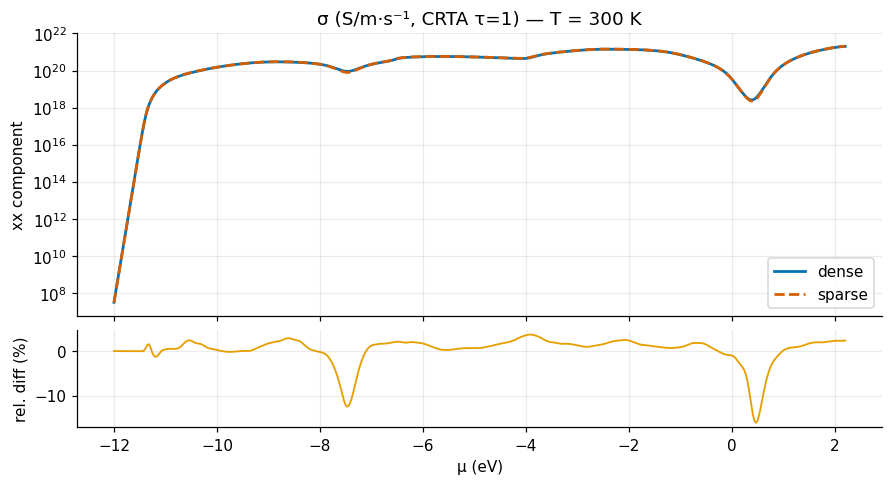

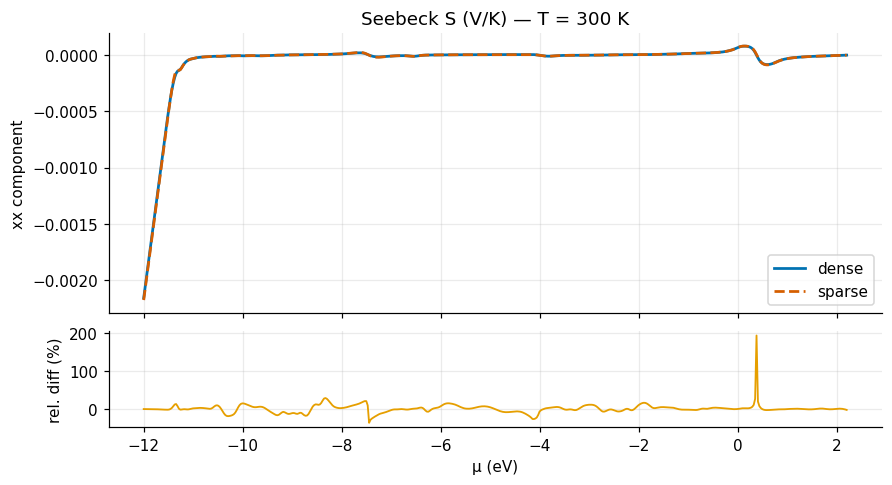

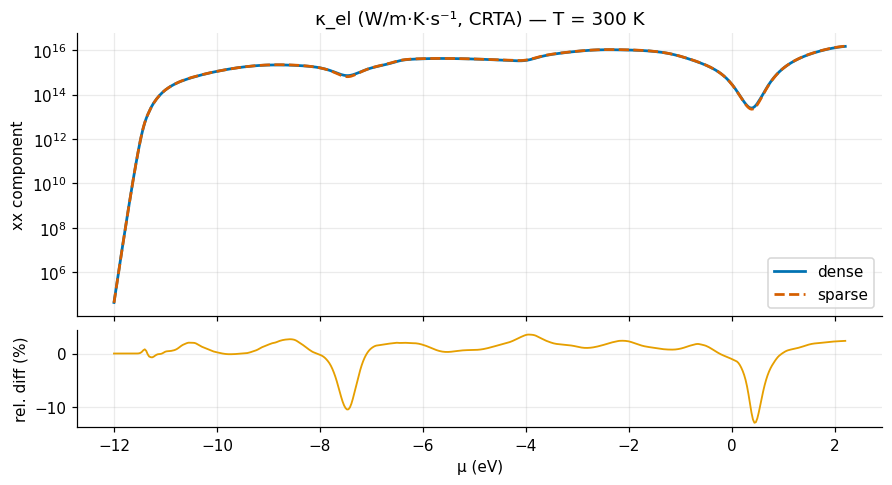

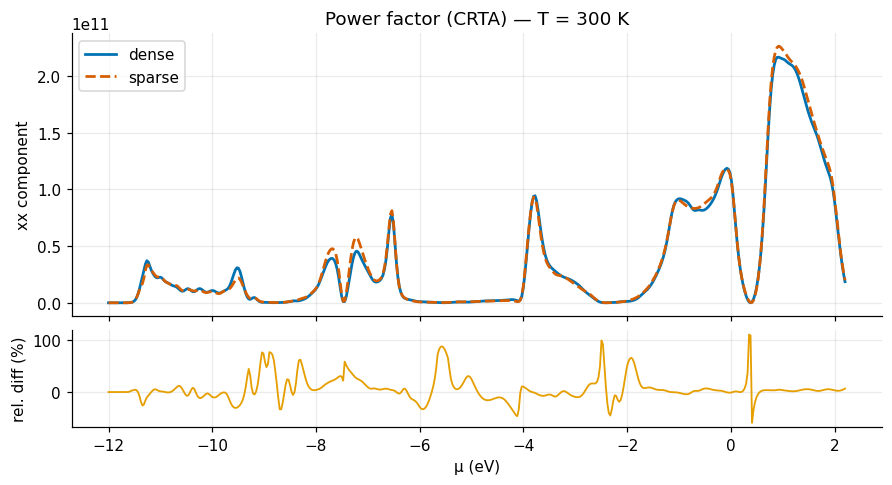

In [4]:
quantities = [('sigmagauss_0.dat', 'σ (S/m·s⁻¹, CRTA τ=1)', 'log'),
              ('Seebeckgauss_0.dat', 'Seebeck S (V/K)', 'linear'),
              ('kappagauss_0.dat', 'κ_el (W/m·K·s⁻¹, CRTA)', 'log'),
              ('PFgauss_0.dat', 'Power factor (CRTA)', 'linear')]

for fname, label, yscale in quantities:
    a = np.loadtxt(f'{REF_DIR}/{fname}')
    b = np.loadtxt(f'{SPARSE_DIR}/{fname}')
    mu, va, vb = a[:, 1], a[:, 2], b[:, 2]   # xx component (cubic: yy, zz identical)
    fig, ax, res = paired_axes()
    if yscale == 'log':
        ax.plot(mu, np.abs(va), color=C_DENSE, lw=1.8, label='dense')
        ax.plot(mu, np.abs(vb), color=C_SPARSE, lw=1.8, ls='--', label='sparse')
        ax.set_yscale('log')
    else:
        ax.plot(mu, va, color=C_DENSE, lw=1.8, label='dense')
        ax.plot(mu, vb, color=C_SPARSE, lw=1.8, ls='--', label='sparse')
    ax.set_ylabel('xx component')
    ax.set_title(f'{label} — T = {a[0, 0]:.0f} K')
    ax.legend(loc='best')
    denom = np.maximum(np.abs(va), 1e-3 * np.abs(va).max())
    res.plot(mu, (vb - va) / denom * 100, color=C_RESID, lw=1.2)
    res.set_ylabel('rel. diff (%)')
    res.set_xlabel('μ (eV)')
    plt.show()